# S&P 500 Equity + Option Analytics: Label Engineering

The strategy reads a signal off a name's listed options and holds the share, so what every
model here predicts is a forward return on the share. This notebook builds the price series
that return is measured on, states which two prices a return is taken between, checks that
every labelled row has a complete forward window inside one security, measures how much
independent information those rows carry once consecutive windows overlap, measures what the
simplest available signal already earns against the label, and writes one file per label.

## Learning objectives

- Turn raw daily bars into a series a return can be taken on, using the adjustment factor
  that carries splits and dividends, and the identifier that stays with a company when its
  ticker changes
- State a forward return as the pair of prices a strategy could have traded at, then check in
  code that every window is complete and stays inside one security
- Derive an up-or-down label from a return without inventing a class for the rows the return
  itself could not fill
- Cut a diagnostic off at the date a label's outcome is known rather than the date its signal
  is read, so that nothing measured here has seen the holdout
- Measure what one unmodified signal earns against the label, under a standard error that
  allows for consecutive labels sharing most of their forward window

## Book reference, prerequisites and artifacts

Chapter 7, Section 7.2. Reads the daily share bars and the option surface through
`load_sp500_daily_bars()` and `load_sp500_options_surface()`, whose coverage
[`01_feasibility_analysis`](01_feasibility_analysis.ipynb) establishes, and
`config/setup.yaml`, which declares the label set, each label's horizon and buffer, and the
holdout boundary. Writes one parquet per declared label into `labels/`, each with a
`.digest.json` sidecar beside it. [`05_evaluation`](05_evaluation.ipynb) reads the primary
label and scores the engineered features against it, the model stages read whichever label
they train on, and `case_studies/utils/cv_window.py` reads each file's own timeline to place
the folds those models are trained and validated on.

In [1]:
"""S&P 500 Equity + Option Analytics - Label Engineering."""

import warnings
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.label_diagnostics import effective_sample_size, panel_autocorrelation
from data import load_sp500_daily_bars, load_sp500_options_surface
from utils.artifact_specs import resolve_label_buffer, resolve_label_horizon
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

warnings.filterwarnings("ignore")

The share bars and the option surface are licensed extracts covering these five years, so the
defaults span the whole of the data. Narrowing the window shortens a run, at the cost of less
history behind the trailing volatility in Section C and fewer years in the development window
that everything from Section E on is computed over.

In [2]:
START_DATE = "2017-01-01"
END_DATE = "2021-12-31"

## Configuration

Everything that defines a label is declared in `config/setup.yaml` and bound here. A horizon
or a boundary typed into a cell is a second copy of a value the rest of the pipeline reads
from the file, and the two drift apart the first time either is edited.

Two quantities are declared under separate keys here, and most case studies hold them equal.
The **outcome horizon** is how long a position is held, and it decides which two prices a
label is measured between. The **buffer** is the gap the walk-forward split leaves between the
end of a training fold and the start of the validation fold after it, counted in trading
sessions because the evaluation calendar is NYSE. A buffer shorter than the horizon would put
a training row whose outcome is still unresolved next to the validation window that resolves
it. The primary label carries ten sessions of buffer against a five-session horizon, twice
what independence requires; each variant carries exactly its own horizon.
`resolve_label_horizon` and `resolve_label_buffer` read the two from their separate keys, and
Section H records both against every label.

In [3]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
LABELS_DIR = CASE_DIR / "labels"
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

PRIMARY_LABEL = setup["labels"]["primary"]
LABEL_NAMES = [PRIMARY_LABEL, *setup["labels"]["variants"]]
HORIZONS = {
    n: int(resolve_label_horizon(CASE_STUDY_ID, n, setup).rstrip("Dd")) for n in LABEL_NAMES
}
BUFFERS = {n: resolve_label_buffer(CASE_STUDY_ID, n, setup) for n in LABEL_NAMES}
DIRECTION_SOURCE = setup["labels"]["classification_eval_label"]
SCALED_LABEL = next(n for n in LABEL_NAMES if "risk_adj" in n)
PLAIN_RETURNS = [n for n in LABEL_NAMES if n.startswith("fwd_ret_") and n != SCALED_LABEL]
PRIMARY_HORIZON = HORIZONS[PRIMARY_LABEL]
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])
PERIODS_PER_YEAR = setup["evaluation"]["periods_per_year"]
ENTITY = "sec_id"
IV_COL = "iv_30_atm"
IV_LAG = int(setup["decision"]["iv_feature_lag"].split("_")[0])
RV_WINDOW = 20

print(f"{PRIMARY_LABEL} is the primary label, and every later stage defaults to it. Each label:")
for name in LABEL_NAMES:
    print(
        f"  {name} is held {HORIZONS[name]} trading sessions, and a training fold ends "
        f"{int(BUFFERS[name].rstrip('Dd'))} sessions before its validation fold begins"
    )
print(
    f"The holdout opens {HOLDOUT_START}; each development window ends a label's own horizon of "
    f"sessions earlier, so nothing measured below resolves inside the holdout"
)

fwd_ret_5d is the primary label, and every later stage defaults to it. Each label:
  fwd_ret_5d is held 5 trading sessions, and a training fold ends 10 sessions before its validation fold begins
  fwd_ret_10d is held 10 trading sessions, and a training fold ends 10 sessions before its validation fold begins
  fwd_ret_risk_adj_5d is held 5 trading sessions, and a training fold ends 5 sessions before its validation fold begins
  fwd_dir_5d is held 5 trading sessions, and a training fold ends 5 sessions before its validation fold begins
  fwd_dir_10d is held 10 trading sessions, and a training fold ends 10 sessions before its validation fold begins
The holdout opens 2021-01-01; each development window ends a label's own horizon of sessions earlier, so nothing measured below resolves inside the holdout


## A. The learning task

The hypothesis is cross-sectional, and it is about a disagreement between two views of the
same company. The option market prices a distribution of outcomes for a name over the coming
month; the share price says what the equity market pays for it today. The claim is that names
whose options are priced richly against what their shares go on to do can be ranked against
each other, and that the ranking pays over the following week. The label is therefore a
forward return on the **share** and not on any option: the strategy reads options and holds
equity.

The decision cadence comes from `setup.yaml`. A Friday close is observed, the option
quantities are lagged one session behind it - the surface summary for a session is stamped at
that session's close and cannot be acted on until the next one - and the resulting portfolio is
entered at Monday's open. That fixes the primary horizon at one trading week. The two-week
variant asks whether the same signal still pays when the portfolio turns over half as often, which
is a question about cost and turnover rather than a second hypothesis. The volatility-scaled
variant asks the same question of a target made comparable across names of very different
volatility. The two direction variants reframe the weekly and the two-weekly return as
classification, which is what the logistic configurations in the model stages train on.

Labels are sampled every session rather than only on Fridays: that buys five times the rows at
the price of overlap between consecutive windows, and Section F measures what those rows are
worth.

## B. Preparation before the label

**These are raw traded prices, and a forward return taken on them is not a return.** Each row
carries `open` and `close` as they printed on the day, and `adj_factor`, the cumulative factor
that puts a price on a comparable footing with the rest of that security's history. Splits,
reverse splits, demergers and cash dividends all move it. Multiplying gives a series in which a
four-for-one split is not a three-quarter loss and a dividend is money the holder received
rather than a fall in the price. Because the factor carries dividends as well as splits, the
label below is a **total return** to a holder of the share.

The entity a label may not cross is the **security**, and the column that identifies it is
`sec_id` rather than the ticker. A ticker gets reassigned after a merger or a spin-off and
`adj_factor` restarts with the new security, so a window that steps across the change reads a
price from one company against a price from another. How much of that this extract carries is
counted below, and most of it arrives with no gap in the series to notice it by.

`session` numbers the market's own trading sessions, and Sections C, D and F count in it rather
than in rows: a name that stops trading for a fortnight and returns has consecutive rows
spanning a hole, and only a market-wide session index shows that. No eligibility filter runs
before the shift, because once rows are dropped from inside a series a shift counts survivors,
the horizon stops being measured in trading sessions, and the window silently spans whatever
was removed. Point-in-time eligibility is applied downstream in `03_financial_features`.

In [4]:
bars = load_sp500_daily_bars(start_date=START_DATE, end_date=END_DATE)
sessions = bars.select("timestamp").unique().sort("timestamp").with_row_index("session")
sessions = sessions.with_columns(pl.col("session").cast(pl.Int64))
prices = (
    bars.join(sessions, on="timestamp")
    .with_columns(
        (pl.col("open") * pl.col("adj_factor")).alias("adj_open"),
        (pl.col("close") * pl.col("adj_factor")).alias("adj_close"),
    )
    .sort([ENTITY, "session"])
)

# Every label's `inputs`: without it a re-run against a refreshed download is invisible.
PRICE_COLS = ["symbol", "sec_id", "timestamp", "open", "close", "adj_factor"]
MARKET_DATA_DIGEST = value_digest(bars, PRICE_COLS)
print(f"market_data digest: {MARKET_DATA_DIGEST}")

pairs = prices.select("symbol", ENTITY).unique()
shared = {
    key: pairs.group_by(key).len().filter(pl.col("len") > 1).height for key in ("symbol", ENTITY)
}
moves = (
    prices.sort(["symbol", "session"])
    .with_columns(
        (pl.col(ENTITY) != pl.col(ENTITY).shift(1).over("symbol")).alias("_moved"),
        pl.col("session").diff().over("symbol").alias("_gap"),
    )
    .filter(pl.col("_moved") & pl.col("_gap").is_not_null())
)

print(f"{prices['symbol'].n_unique()} tickers over {sessions.height:,} sessions")
print(f"{prices.height:,} name-sessions in {prices[ENTITY].n_unique()} securities")
print(
    f"{shared['symbol']} tickers cover more than one security and {shared[ENTITY]} securities "
    f"trade under more than one ticker; {moves.filter(pl.col('_gap') == 1).height} of "
    f"{moves.height} changeovers land on the very next session"
)

market_data digest: f56578e899bc71b3


638 tickers over 1,259 sessions
635,703 name-sessions in 629 securities
15 tickers cover more than one security and 24 securities trade under more than one ticker; 12 of 15 changeovers land on the very next session


## C. Label construction

One execution convention, written once and applied at both horizons:

$$r^{(h)}_{i,t} = \frac{C_{i,t+h}}{O_{i,t+1}} - 1$$

where $O$ and $C$ are the adjusted open and close of security $i$, and $t+h$ counts $h$
**trading sessions**. The signal is read at the close of $t$, the position is entered at the
next open, and it is exited $h$ sessions later at the close. That is the convention
`setup.yaml` declares under `decision`, and it is deliberately not Chapter 7.2's close-to-close
form: a label anchored on the close of $t$ credits the strategy with the overnight move between
the signal and the first price it can trade at.

The library's `fixed_time_horizon_labels` cannot express this convention: it divides by the
price at $t$ in the same column it takes the numerator from, and here the numerator is a close
and the denominator an open. The construction is written out below instead, under the rule the
library would have applied - a window counts only if every price in it exists and its two ends
are exactly $h$ sessions apart.

Three working columns are computed on the complete series, because each is only meaningful
before a row is dropped: `from_end`, how far back a row sits from the last session its security
trades; `session`, the market's own session index; and the one-session return the scaled
label's trailing volatility is built from.

In [5]:
def forward_return(df: pl.DataFrame, horizon: int, name: str) -> pl.DataFrame:
    """Next-open-to-close return over `horizon` sessions, null unless the window is complete."""
    entry = pl.col("adj_open").shift(-1).over(ENTITY)
    exit_price = pl.col("adj_close").shift(-horizon).over(ENTITY)
    spans_horizon = pl.col("session").shift(-horizon).over(ENTITY) - pl.col("session") == horizon
    return df.with_columns(
        pl.when(spans_horizon & (entry > 0) & (exit_price > 0))
        .then(exit_price / entry - 1)
        .alias(name)
    )


ONE_SESSION = pl.col("session").diff().over(ENTITY) == 1
labels_df = prices.with_columns(
    (pl.len().over(ENTITY) - 1 - pl.int_range(pl.len()).over(ENTITY)).alias("from_end"),
    pl.when(ONE_SESSION).then(pl.col("adj_close").pct_change().over(ENTITY)).alias("_daily_ret"),
)
for label_name in PLAIN_RETURNS:
    labels_df = forward_return(labels_df, HORIZONS[label_name], label_name)

The scaled variant divides the weekly return by the volatility realized over the previous
twenty sessions, about a month of trading, annualized on the sessions per year `setup.yaml`
declares, so that a five percent week
in a quiet utility and a five percent week in a semiconductor are not the same target value.
The denominator is guarded twice. A daily return is only a daily return between two adjacent
sessions, so it is null wherever the security missed the session before, and the rolling window
stays null until it holds a full month of consecutive returns rather than closing over the gap
as though nothing had been missed. And a security that did not move at all
over the lookback has an undefined ratio, which is left undefined rather than floored at a
constant that would answer with a very large number instead.

The direction variants are the sign of the return they come from, and
`setup.yaml::labels.classification_eval_label` says which return that is. **The guard on the
outer `when` is the whole point of the cell.** In Polars a null predicate is not true, so
`when(ret > 0).then(1).otherwise(0)` writes a confident zero wherever the return is null - in
every row of the last week of every security, which have no forward window at all. Those rows
cannot be removed afterwards, because the value is not null, it is wrong.

In [6]:
trailing_rv = pl.col("_daily_ret").rolling_std(RV_WINDOW).over(ENTITY) * PERIODS_PER_YEAR**0.5
labels_df = labels_df.with_columns(trailing_rv.alias("_trailing_rv"))
labels_df = labels_df.with_columns(
    pl.when(pl.col("_trailing_rv") > 0)
    .then(pl.col(PRIMARY_LABEL) / pl.col("_trailing_rv"))
    .alias(SCALED_LABEL)
)
for label_name, source in DIRECTION_SOURCE.items():
    sign = pl.when(pl.col(source).is_not_null()).then((pl.col(source) > 0).cast(pl.Int32))
    labels_df = labels_df.with_columns(sign.alias(label_name))

## D. Window validity

A shift always returns something; the question is whether what it returns is the quantity the
label claims. Each property below fails silently and leaves plausible numbers behind, so each
is asserted rather than described.

The second assertion is a full reconciliation rather than a bound. Every row carrying no label
is attributed to exactly one cause - the tail of its security's series, a hole between the two
ends of the window, or a missing price at one end - and the counts have to sum to the height of
the frame. A label crossing a security boundary, or a short label masked by a longer one's null
set, breaks that identity.

The third assertion bounds the calendar span a labelled window may cover, and it is what tests
the session count against the calendar instead of against itself: $h$ trading sessions span
about $7h/5$ calendar days on a five-session week, plus a week for exchange holidays. A
security that stops trading for a year and returns would produce windows far wider than any
holiday pattern accounts for.

In [7]:
for label_name in [*PLAIN_RETURNS, SCALED_LABEL]:
    horizon = HORIZONS[label_name]
    checked = labels_df.with_columns(
        (pl.col("timestamp").shift(-horizon).over(ENTITY) - pl.col("timestamp"))
        .dt.total_days()
        .alias("_span")
    )
    tail = pl.col("from_end") < horizon
    holed = pl.col("session").shift(-horizon).over(ENTITY) - pl.col("session") != horizon
    unfilled = ~tail & ~holed & pl.col(label_name).is_null()
    warm_up = unfilled & pl.col(PRIMARY_LABEL).is_not_null() & (label_name == SCALED_LABEL)
    causes = {"no forward window": tail, "a hole in the window": ~tail & holed}
    causes |= {"no trailing volatility yet": warm_up, "a missing price": unfilled & ~warm_up}
    labelled = checked.drop_nulls(label_name)

    # 1. An incomplete forward window is null, never a value.
    assert checked.filter(tail)[label_name].null_count() == checked.filter(tail).height
    # 2. Labelled rows plus the causes account for every row, each cause once.
    counts = {cause: checked.filter(cond).height for cause, cond in causes.items()}
    assert labelled.height + sum(counts.values()) == checked.height, (label_name, counts)
    # 3. No labelled window spans more calendar days than holidays alone can explain.
    tolerance = -(-horizon * 7 // 5) + 7
    assert labelled.filter(pl.col("_span") > tolerance).height == 0, label_name
    unlabelled = ", ".join(f"{n:,} with {cause}" for cause, n in counts.items() if n)
    print(
        f"{label_name}: {labelled.height:,} labelled, spans up to {labelled['_span'].max()}d "
        f"against a {tolerance}d tolerance; unlabelled {unlabelled}"
    )

# 4. No direction label is derived from a null return.
for label_name, source in DIRECTION_SOURCE.items():
    fabricated = labels_df.filter(pl.col(source).is_null() & pl.col(label_name).is_not_null())
    assert fabricated.height == 0, (label_name, fabricated.height)
    print(f"{label_name}: the sign of {source}, and null wherever {source} is")

fwd_ret_5d: 632,522 labelled, spans up to 11d against a 14d tolerance; unlabelled 3,135 with no forward window, 34 with a hole in the window, 12 with a missing price


fwd_ret_10d: 629,378 labelled, spans up to 18d against a 21d tolerance; unlabelled 6,249 with no forward window, 64 with a hole in the window, 12 with a missing price
fwd_ret_risk_adj_5d: 620,010 labelled, spans up to 11d against a 14d tolerance; unlabelled 3,135 with no forward window, 34 with a hole in the window, 12,512 with no trailing volatility yet, 12 with a missing price
fwd_dir_5d: the sign of fwd_ret_5d, and null wherever fwd_ret_5d is
fwd_dir_10d: the sign of fwd_ret_10d, and null wherever fwd_ret_10d is


Position zero below is each security's last session. The non-null rate has to fall to zero over
exactly the last `horizon` positions and sit flat beyond them, and each direction label has to
fall exactly where the return it comes from does. A scalar count of valid rows shows neither
failure this catches: a tail written as a confident zero reads as fully valid, and a short
label masked by a longer one's null set reads as the longer one's count. The figure reads only
which rows are null and never a label value, so it covers the whole extract rather than the
development window that Sections E to G are restricted to.

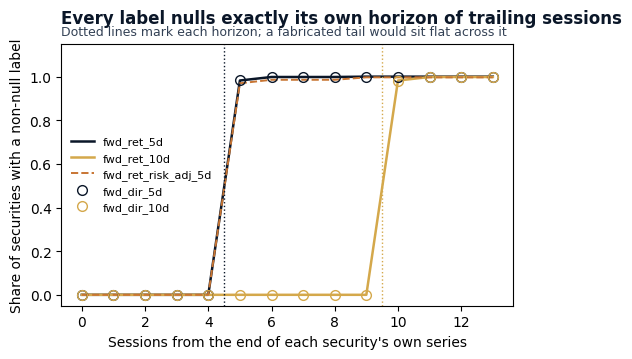

In [8]:
profile = (
    labels_df.filter(pl.col("from_end") <= max(HORIZONS.values()) + 3)
    .group_by("from_end")
    .agg([pl.col(n).is_not_null().mean().alias(n) for n in LABEL_NAMES])
    .sort("from_end")
)
family = {5: COLORS["blue"], 10: COLORS["amber"]}
styles = {n: dict(lw=1.8, color=family[HORIZONS[n]]) for n in LABEL_NAMES}
styles |= {n: dict(marker="o", ms=7, mfc="none", ls="none", **styles[n]) for n in DIRECTION_SOURCE}
styles[SCALED_LABEL] = dict(lw=1.4, ls="--", color=COLORS["copper"])

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for label_name in LABEL_NAMES:
    ax.plot(profile["from_end"], profile[label_name], label=label_name, **styles[label_name])
for horizon, colour in family.items():
    ax.axvline(horizon - 0.5, color=colour, linestyle=":", lw=1)
ax.set_xlabel("Sessions from the end of each security's own series")
ax.set_ylabel("Share of securities with a non-null label")
ax.set_ylim(-0.05, 1.15)
add_message_title(
    ax,
    "Every label nulls exactly its own horizon of trailing sessions",
    subtitle="Dotted lines mark each horizon; a fabricated tail would sit flat across it",
)
ax.legend(loc="center left", frameon=False, fontsize=8)
show_with_alt(fig, "Non-null rate of each label by position from the end of a security's series.")

## E. Distribution and base rate

What scale is each label, and does it mean the same thing across names and across regimes?
Everything from here through Section G is computed on the development window only, and that
window is cut at the date each label's outcome is **known** rather than at the date its signal
is read. A row observed shortly before the holdout still resolves inside it, so a filter on the
observation date leaves holdout outcomes in the diagnostic. Each label is cut at its own
endpoint, because the horizons differ. The label files still carry every row: the cut governs
what this notebook looks at, not what it writes.

In [9]:
dev = {
    name: labels_df.with_columns(
        pl.col("timestamp").shift(-horizon).over(ENTITY).alias("_label_end")
    )
    .filter(pl.col("_label_end") < HOLDOUT_START)
    .drop_nulls(name)
    for name, horizon in HORIZONS.items()
}
for label_name, frame in dev.items():
    print(f"{label_name}: {frame.height:,} development rows through {frame['timestamp'].max()}")

fwd_ret_5d: 505,398 development rows through 2020-12-23
fwd_ret_10d: 502,366 development rows through 2020-12-16
fwd_ret_risk_adj_5d: 493,283 development rows through 2020-12-23
fwd_dir_5d: 505,398 development rows through 2020-12-23
fwd_dir_10d: 502,366 development rows through 2020-12-16


Both return labels go on one axis with identical bins and a logarithmic count axis. The claim
the figure has to support is about shape rather than width - two dispersion scalars carry the
width - and the shape is that the longer horizon adds mass across the whole body rather than
only in the tails. The axis is symmetric and narrower than either label's range, so rows
outside it are counted below rather than drawn.

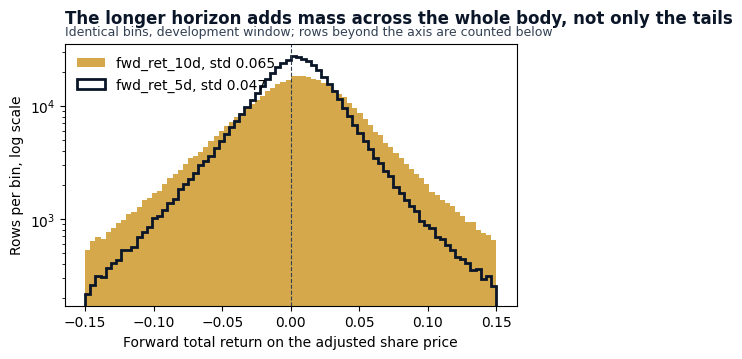

fwd_ret_5d: std 0.04694, kurtosis 16.48, 7,389 rows beyond the axis
fwd_ret_10d: std 0.06535, kurtosis 10.09, 17,560 rows beyond the axis
fwd_ret_risk_adj_5d: std 0.16627, kurtosis 7.15
width ratio 1.39 against 1.41 under square-root-of-horizon scaling


In [10]:
bins = np.linspace(-0.15, 0.15, 81)
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
hist_styles = (dict(color=COLORS["amber"]), dict(color=COLORS["blue"], histtype="step", lw=2))
for label_name, style in zip(PLAIN_RETURNS[::-1], hist_styles, strict=True):
    series = dev[label_name][label_name]
    ax.hist(series.to_numpy(), bins=bins, label=f"{label_name}, std {series.std():.3f}", **style)
ax.axvline(0, color=COLORS["neutral"], linestyle="--", lw=0.8)
ax.set_yscale("log")
ax.set_xlabel("Forward total return on the adjusted share price")
ax.set_ylabel("Rows per bin, log scale")
add_message_title(
    ax,
    "The longer horizon adds mass across the whole body, not only the tails",
    subtitle="Identical bins, development window; rows beyond the axis are counted below",
)
ax.legend(loc="upper left", frameon=False)
show_with_alt(fig, "Histograms of the two forward-return labels on identical bins, log counts.")

for label_name in [*PLAIN_RETURNS, SCALED_LABEL]:
    series, on_axis = dev[label_name][label_name], label_name != SCALED_LABEL
    beyond = f", {int((series.abs() > bins[-1]).sum()):,} rows beyond the axis" if on_axis else ""
    print(f"{label_name}: std {series.std():.5f}, kurtosis {series.kurtosis():.2f}{beyond}")
short, long_ = (dev[n][n].std() for n in PLAIN_RETURNS)
root_h = (HORIZONS[PLAIN_RETURNS[1]] / PRIMARY_HORIZON) ** 0.5
print(f"width ratio {long_ / short:.2f} against {root_h:.2f} under square-root-of-horizon scaling")

The scaled variant lives on a different axis, a multiple of the name's own volatility rather
than a return, so it is not drawn on the return axis above and its width is printed instead.
What the division does is visible in the kurtosis: a five percent week is an ordinary week in
one name and an extreme one in another, and pooling them unscaled puts the ordinary weeks of
the most volatile names where a model reads them as the extremes of the target.

Chapter 7.2 asks for the base rate to be tracked through time. For a continuous label ranked
across a cross-section, the quantity that has to be stable is the spread the model ranks
within: where it is not, the same rank correlation buys a different amount of return. The
spread is taken across names on each session first and only then averaged over the year.
Pooling every name-session in a year into one standard deviation instead adds the movement of
the market's own mean from session to session to the spread across names on a session, and a
ranking model is scored on the second alone. For a direction label the same question is the
share of rows in the positive class, which is what a classifier's threshold sits against.

In [11]:
def annual_profile(name: str) -> pl.DataFrame:
    """Per year: the spread across names on a session for a return, the positive share for a sign."""
    frame = dev[name].with_columns(pl.col("timestamp").dt.year().alias("year"))
    if name in DIRECTION_SOURCE:
        return frame.group_by("year").agg(pl.col(name).mean().alias("value")).sort("year")
    return (
        frame.group_by("timestamp", "year")
        .agg(pl.col(name).std().alias("value"))
        .group_by("year")
        .agg(pl.col("value").mean())
        .sort("year")
    )


annual = {n: annual_profile(n) for n in [*PLAIN_RETURNS, *DIRECTION_SOURCE]}

The two panels share a year axis so the same regime can be found in both. The dashed line on the
right marks an even split, which is where a direction label carries no information at all before
a model sees it. A share that sits that close to its reference needs an axis that does not start
at zero, so it is drawn as a series against the reference rather than as a bar whose baseline
would have to carry the comparison.

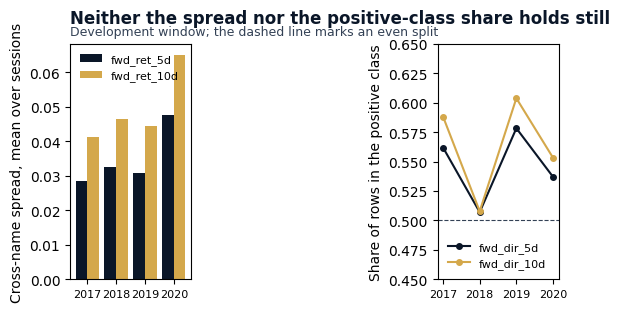

fwd_ret_5d: 0.0284 in 2017 rising to 0.0476 in 2020
fwd_ret_10d: 0.0412 in 2017 rising to 0.0650 in 2020
fwd_dir_5d: 0.5070 in 2018 rising to 0.5783 in 2019
fwd_dir_10d: 0.5078 in 2018 rising to 0.6038 in 2019


In [12]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE["dual_h_tall"])
for offset, name in zip((-0.2, 0.2), PLAIN_RETURNS, strict=True):
    table = annual[name]
    axes[0].bar(
        table["year"] + offset, table["value"], 0.4, color=family[HORIZONS[name]], label=name
    )
for name in DIRECTION_SOURCE:
    table = annual[name]
    axes[1].plot(
        table["year"], table["value"], "o-", ms=4, color=family[HORIZONS[name]], label=name
    )
axes[1].axhline(0.5, color=COLORS["neutral"], linestyle="--", lw=0.8)
axes[1].set_ylim(0.45, 0.65)
axes[0].set_ylabel("Cross-name spread, mean over sessions")
axes[1].set_ylabel("Share of rows in the positive class")
for ax, loc in zip(axes, ("upper left", "lower left"), strict=True):
    ax.set_xticks(annual[PRIMARY_LABEL]["year"].to_list())
    ax.tick_params(axis="x", labelsize=8)
    ax.legend(loc=loc, frameon=False, fontsize=8)
add_message_title(
    axes[0],
    "Neither the spread nor the positive-class share holds still",
    subtitle="Development window; the dashed line marks an even split",
)
fig.tight_layout()
show_with_alt(fig, "Annual cross-name dispersion and annual positive-class share, by label.")

for label_name, table in annual.items():
    peak, low = (table.sort("value", descending=d).row(0, named=True) for d in (True, False))
    print(
        f"{label_name}: {low['value']:.4f} in {low['year']} rising to {peak['value']:.4f} in {peak['year']}"
    )

On the development window the weekly label has a standard deviation of 0.04694 and the
two-weekly one 0.06535, a ratio of 1.39 against the 1.41 that square-root-of-horizon scaling
implies; dividing the weekly label by each name's trailing volatility cuts its kurtosis from
16.48 to 7.15. Neither the spread nor the base rate is stable: the daily cross-name spread of
the weekly label runs from 0.0284 in 2017 to 0.0476 in 2020, and the share of weeks that end
higher from 0.5070 in 2018 to 0.5783 in 2019.

## F. Overlap and effective sample size

Sampling a multi-session label at every session makes consecutive rows share most of their
forward window, so the row count overstates the evidence. Two measurements answer that in
different units: how fast the overlap decays, and what the rows are worth once it is priced in.
`effective_sample_size` applies Chapter 7.2's average-uniqueness weighting per security,
because concurrency is a property of one security's own overlapping windows.

Both are counted on `session`, the grid the label was built on, rather than on position among
the rows that survive into the development frame. Closing over a security's own trading gap
would pair windows that share nothing and report the overlap as larger than it is.

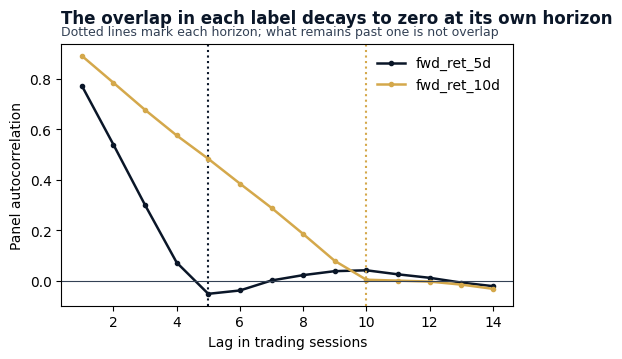

In [13]:
max_lag = max(HORIZONS.values()) + 4
acf = {
    name: panel_autocorrelation(
        dev[name], name, max_lag=max_lag, bar_col="session", entity_col=ENTITY
    )
    for name in PLAIN_RETURNS
}

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
lags = np.arange(1, max_lag + 1)
for label_name in PLAIN_RETURNS:
    colour = family[HORIZONS[label_name]]
    ax.plot(lags, acf[label_name], "o-", ms=3, c=colour, lw=1.8, label=label_name)
    ax.axvline(HORIZONS[label_name], color=colour, linestyle=":", lw=1.5)
ax.axhline(0, color=COLORS["neutral"], lw=0.8)
ax.set_xlabel("Lag in trading sessions")
ax.set_ylabel("Panel autocorrelation")
add_message_title(
    ax,
    "The overlap in each label decays to zero at its own horizon",
    subtitle="Dotted lines mark each horizon; what remains past one is not overlap",
)
ax.legend(loc="upper right", frameon=False)
show_with_alt(fig, "Panel autocorrelation of both return labels against lag in trading sessions.")

The second measurement turns the same overlap into a row count. Average uniqueness weights each
row by the share of its forward window no concurrent label also spans, and summing those weights
gives the number of independent observations the frame is worth. A horizon-h label consumes the
h returns realized over its window and its neighbour one session later shares h-1 of them, so
average uniqueness converges to 1/h and the ratio below is what it converges to.

In [14]:
for label_name, horizon in HORIZONS.items():
    n_rows, n_eff = effective_sample_size(
        dev[label_name], horizon=horizon, bar_col="session", entity_col=ENTITY
    )
    print(
        f"{label_name}: N={n_rows:,}, N_eff={n_eff:,.0f}, ratio {n_eff / n_rows:.4f} against "
        f"{1 / horizon:.4f} for windows overlapping this fully"
    )
for label_name in PLAIN_RETURNS:
    decay, horizon = acf[label_name], HORIZONS[label_name]
    print(
        f"{label_name}: autocorrelation {decay[0]:.3f} at lag one, {decay[horizon - 1]:.3f} at lag {horizon}"
    )

fwd_ret_5d: N=505,398, N_eff=101,566, ratio 0.2010 against 0.2000 for windows overlapping this fully


fwd_ret_10d: N=502,366, N_eff=50,781, ratio 0.1011 against 0.1000 for windows overlapping this fully


fwd_ret_risk_adj_5d: N=493,283, N_eff=99,140, ratio 0.2010 against 0.2000 for windows overlapping this fully


fwd_dir_5d: N=505,398, N_eff=101,566, ratio 0.2010 against 0.2000 for windows overlapping this fully


fwd_dir_10d: N=502,366, N_eff=50,781, ratio 0.1011 against 0.1000 for windows overlapping this fully
fwd_ret_5d: autocorrelation 0.772 at lag one, -0.052 at lag 5
fwd_ret_10d: autocorrelation 0.891 at lag one, 0.004 at lag 10


The weekly label's 505,398 development rows carry 101,566 effective observations, a ratio of
0.2010 against the 0.2000 a fully overlapped five-session window implies; the two-weekly
label's 502,366 rows carry 50,781, a ratio of 0.1011 against 0.1000. Both sit just above the
reference value, because a security that stops trading ends an overlap early. Panel
autocorrelation falls from 0.772 at lag one to -0.052 at lag five for the weekly label, and
from 0.891 to 0.004 at lag ten for the two-weekly one. The purge gap a fold needs is set by the
forward window itself, not by these counts.

## G. Baseline floor

One signal against the primary label on the development window, with no feature
engineering: the thirty-day at-the-money implied volatility whose persistence
[`01_feasibility_analysis`](01_feasibility_analysis.ipynb) measured, lagged by the session
`setup.yaml::decision.iv_feature_lag` declares, and read raw. Every option-derived feature in
`03_financial_features` is built out of that quantity, so it is the floor those features have
to clear, and measuring it before building them is what makes a later improvement mean
something.

The lag is a market session inside the security, not one row of the surface. Coverage of the
surface swings on a monthly cycle, so on the narrow weeks a name's previous quoted row can be
a fortnight back, and a shift taken over the surface's own rows would hand the model a
fortnight-old volatility while calling it yesterday's. Joining the surface onto the dense
price panel first makes the missing sessions visible as nulls, and the guard drops them.

The information coefficient is the cross-sectional rank correlation on each session, averaged
over sessions, which is the quantity a ranking model is scored on; pooling every name-session
instead mixes a cross-sectional claim with a time-series one. The series is put back in time
order before the standard error reads it, because that standard error is built out of the
correlations between one session and the next.

A correlation over a handful of names is noise, so a session is scored only where at least a
minimum number of names are quoted. That minimum is half the median cross-section rather than
a fixed count, so it means the same thing on a universe of another size, and the sessions that
fall below it are dropped from the statistic - the count printed below is how many of the
window's sessions were scored. The standard error is HAC-adjusted, because the series of
per-session correlations inherits the label's overlap and a naive statistic would treat five
consecutive sessions of one week's return as five separate pieces of evidence.

In [15]:
surface = load_sp500_options_surface(start_date=START_DATE, end_date=END_DATE)
carrier = (
    prices.select("timestamp", "symbol", ENTITY, "session")
    .join(surface.select("timestamp", "symbol", IV_COL), on=["timestamp", "symbol"], how="left")
    .sort([ENTITY, "session"])
    .with_columns(
        pl.when(ONE_SESSION).then(pl.col(IV_COL).shift(IV_LAG).over(ENTITY)).alias("signal")
    )
    .drop_nulls("signal")
)
baseline = dev[PRIMARY_LABEL].join(
    carrier.select("timestamp", "symbol", "signal"), on=["timestamp", "symbol"], how="inner"
)
min_obs = int(baseline.group_by("timestamp").len()["len"].median() // 2)

ic = cross_sectional_ic_series(
    baseline,
    baseline,
    pred_col="signal",
    ret_col=PRIMARY_LABEL,
    date_col="timestamp",
    entity_col="symbol",
    min_obs=min_obs,
).sort("timestamp")  # a HAC autocovariance over a permutation of the time axis means nothing
stats = compute_ic_hac_stats(ic, ic_col="ic", label_horizon=PRIMARY_HORIZON)

print(
    f"Baseline: {IV_COL} lagged {IV_LAG} session against {PRIMARY_LABEL}, "
    f"{baseline.height:,} rows, minimum cross-section {min_obs} names\n"
    f"  sessions scored {stats['n_periods']:,} of the {ic.height:,} in the window, "
    f"mean IC {stats['mean_ic']:.4f}\n"
    f"  HAC t {stats['t_stat']:.2f} on {stats['effective_lags']} Bartlett lags, "
    f"naive t {stats['naive_t_stat']:.2f}, p {stats['p_value']:.3g}"
)

Baseline: iv_30_atm lagged 1 session against fwd_ret_5d, 329,212 rows, minimum cross-section 130 names
  sessions scored 1,001 of the 1,001 in the window, mean IC -0.0072
  HAC t -0.50 on 6 Bartlett lags, naive t -0.93, p 0.614


The lagged at-the-money volatility earns a mean information coefficient of -0.0072 against the
weekly label. Every one of the 1,001 sessions in the development window quotes at least the 130
names the minimum cross-section asks for, so all 1,001 are scored. Under the naive standard
error that is a t-statistic of -0.93; the Newey-West rule picks 6 lags here, above the four the
horizon alone requires, and the HAC statistic is -0.50 with a p-value of 0.614. The floor a
feature has to clear is a mean IC the data cannot separate from zero, so the sign of it carries
nothing either.

## H. Artifacts and the audit record

Beside each label file the notebook writes a second, small JSON file, `<label>.digest.json`.
It is there so that a later stage can tell whether the label it is reading still holds the
values it was built against. It does that with a **digest**: a short hash of the values in the
file, which changes if any value changes and stays the same if the same values are written
again. The sidecar records that digest, the row count, the columns, the key columns, the
notebook that wrote the file, and the digest of the price data the label was built from. The
last of those is what ties a label to a data vintage - without it, a re-run against a refreshed
download looks exactly like a re-run against the same one.

The key is `timestamp` and `symbol`, the pair every file downstream joins on. `sec_id` is the
entity the label was built inside and is not carried into the file.

The folds that train models are derived per label by `case_studies/utils/cv_window.py` from
`config/setup.yaml` and the timeline of the label parquet written here, so which rows land in
these files is what sets where the fold boundaries fall.

In [16]:
KEYS = ["timestamp", "symbol"]
for label_name in LABEL_NAMES:
    record = write_artifact(
        labels_df.select([*KEYS, label_name]).drop_nulls(),
        LABELS_DIR / f"{label_name}.parquet",
        keys=KEYS,
        written_by="02_labels",
        inputs={"market_data": MARKET_DATA_DIGEST},
    )
    print(f"{label_name}.parquet: {record['n_rows']:,} rows, digest {record['digest']}")

fwd_ret_5d.parquet: 632,522 rows, digest 7280bba2710cfa08
fwd_ret_10d.parquet: 629,378 rows, digest 1f02b172e1edf0b8
fwd_ret_risk_adj_5d.parquet: 620,010 rows, digest ab5f2381de72fc3f
fwd_dir_5d.parquet: 632,522 rows, digest e9bc4b44f7f8c3d8
fwd_dir_10d.parquet: 629,378 rows, digest 0a15949f45d521df


The record Chapter 7.2 requires to close a label definition, one row per label, built from the
values computed above rather than written by hand. The horizon and the buffer are printed
separately, because this is the case study that separates them.

In [17]:
readers = {
    PRIMARY_LABEL: "05_evaluation.py, which scores the features against it, and the model stages"
}
print("\nLabel audit record")
for label_name, horizon in HORIZONS.items():
    frame, source = dev[label_name], DIRECTION_SOURCE.get(label_name)
    anchor = f"the sign of {source}" if source else "the adjusted open of the session after t"
    buffer_sessions = int(BUFFERS[label_name].rstrip("Dd"))
    print(
        f"\n{label_name}\n  anchor       {anchor}"
        f"\n  horizon      {horizon} trading sessions, against a {buffer_sessions}-session fold buffer"
        f"\n  resolution   fixed at the close of t+{horizon}; daily bars need no tie-break"
        f"\n  overlap      {horizon - 1} sessions shared by consecutive rows"
        f"\n  base rate    mean {frame[label_name].mean():+.5f}, std {frame[label_name].std():.5f}"
        f"\n  consumed by  {readers.get(label_name, 'the model stages, as a variant')}"
    )


Label audit record

fwd_ret_5d
  anchor       the adjusted open of the session after t
  horizon      5 trading sessions, against a 10-session fold buffer
  resolution   fixed at the close of t+5; daily bars need no tie-break
  overlap      4 sessions shared by consecutive rows
  base rate    mean +0.00223, std 0.04694
  consumed by  05_evaluation.py, which scores the features against it, and the model stages

fwd_ret_10d
  anchor       the adjusted open of the session after t
  horizon      10 trading sessions, against a 10-session fold buffer
  resolution   fixed at the close of t+10; daily bars need no tie-break
  overlap      9 sessions shared by consecutive rows
  base rate    mean +0.00491, std 0.06535
  consumed by  the model stages, as a variant

fwd_ret_risk_adj_5d
  anchor       the adjusted open of the session after t
  horizon      5 trading sessions, against a 5-session fold buffer
  resolution   fixed at the close of t+5; daily bars need no tie-break
  overlap      4 ses

## Key takeaways

1. **On a raw equity panel, rebuild the tradable price series before writing any label.** A
   split, a spin-off, or a ticker reassigned to another company all leave the raw prices intact
   and the return between them meaningless, and none of them raises anything.
2. **Check the window in code, and account for every unlabelled row.** An incomplete window,
   a hole in a security's series and a window crossing a change of security all fail without
   raising, and a reconciliation that has to balance catches what a row count passes over.
3. **Derive a discrete label under an explicit null guard.** A comparison against a null return
   is false rather than null, so the naive form writes a confident class into every row the
   return could not fill, and no later `drop_nulls` can find it.
4. **Cut a diagnostic off at the label's endpoint, not at its observation date.** A row
   observed before the holdout whose outcome resolves inside it is a holdout row, so each
   label's usable boundary is the holdout date minus its own horizon, counted in trading
   sessions.
5. **A row count overstates the evidence when forward windows overlap.** The effective count
   says by how much, and it does not set the purge gap - the forward window does.

**Known limitations.** The label is a total return to a holder of the share, because the
adjustment factor carries dividends as well as splits; a strategy credited only with price
returns would be measured against a slightly different target. The universe is every ticker in
the extract rather than a liquidity screen applied point in time. The hole rule tests each
security's own position on the market calendar, so it finds an absent session and not a session
on which the name barely traded. The baseline is one signal, read raw off the surface with no
adjustment for the level of volatility a name usually carries.

**Next**: `03_financial_features.py` builds the volatility-surface, variance-premium, skew and
equity-momentum features from the same two sources. `05_evaluation.py` is where those features
are first scored against the primary label written here.